## S1-Task Vehicle Predict

### Goal 目标

API key = KGAT_53788d07f5f72126b602b031635897c1

## 1 Packages and data load (5mins) 库与数据加载

- [x] Import packages
- [x] Set directories
- [x] Load dataset
- [x] Preview data

In [61]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.core.dtypes.common import is_numeric_dtype
from pyexpat import features

from pygments.lexer import include
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# config
sns.set_theme(style="whitegrid")

In [4]:
DATA_DIR = Path(r"vehicles")

train_path = DATA_DIR / "vehicles_train.csv"
test_path = DATA_DIR / "vehicles_test.csv"
description_path = DATA_DIR / "data_description.txt"

print("当前目录:", DATA_DIR.resolve())
print("train.csv:", train_path.exists())
print("test.csv :", test_path.exists())
print("description:", description_path.exists())

当前目录: C:\Users\Tolia\Documents\GitHub\ITMO-MA\EnterExam\ai\Practice\S1-1\vehicles
train.csv: True
test.csv : True
description: False


In [5]:
# NA_VALUES = []

train = pd.read_csv(train_path,keep_default_na=True) # na_values=NA_VALUES
test = pd.read_csv(test_path, keep_default_na=True) # na_values=NA_VALUES

In [6]:
print("train shape:", train.shape)
print("test shape :", test.shape)

display(train.head())
display(test.head())

train shape: (376522, 23)
test shape : (50044, 22)


,listing_id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,...,drive,size,type,paint_color,description,county,state,lat,long,posting_date
0,veh_d420fe9aca09,gainesville,33990,2020.0,ford,ranger supercrew xl pickup,good,NaN,other,1193.0,...,NaN,NaN,pickup,NaN,Carvana is the safer way to buy a car During t...,NaN,fl,29.670000,-82.330000,2021-05-04T13:41:41-0400
1,veh_dbe8c873c362,atlanta,30690,2014.0,ram,pickup 1500,NaN,8 cylinders,gas,74500.0,...,rwd,full-size,pickup,grey,Most common questions about this vehicle: Wan...,NaN,ga,34.087409,-83.945058,2021-05-03T06:52:28-0400
2,veh_43c98563244a,danville,36590,2017.0,chevrolet,tahoe lt sport utility,good,NaN,other,60476.0,...,NaN,NaN,SUV,silver,Carvana is the safer way to buy a car During t...,NaN,va,36.580000,-79.400000,2021-04-10T09:04:50-0400
3,veh_0ec1871fa0ac,santa maria,14995,2011.0,ford,explorer base,good,6 cylinders,gas,77597.0,...,fwd,NaN,other,silver,2011*Ford*Explorer*Base -Stock 1485 The Auto S...,NaN,ca,36.683288,-121.652752,2021-05-03T10:21:23-0700
4,veh_df1e58878111,hartford,388,2002.0,mercury,sable,NaN,NaN,gas,150000.0,...,NaN,NaN,NaN,NaN,Don't get into a car payment you can't afford....,NaN,ct,41.448297,-72.828444,2021-04-25T18:15:06-0400


,listing_id,region,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,...,drive,size,type,paint_color,description,county,state,lat,long,posting_date
0,veh_821ca226bd74,nashville,2015.0,ford,f-150,excellent,NaN,gas,101366.0,clean,...,rwd,NaN,pickup,black,Call ☏ (615) 992−3147 First Class Auto Sales ...,NaN,tn,36.292259,-86.733337,2021-04-28T15:00:14-0500
1,veh_c35dafc9d02c,green bay,2001.0,pontiac,grand prix gt,excellent,6 cylinders,gas,117000.0,clean,...,fwd,NaN,coupe,brown,"2001 Pontiac Grand Prix. 117,000 miles. Brand ...",NaN,wi,44.493600,-88.079700,2021-04-30T18:08:41-0500
2,veh_82566b7397a7,asheville,2002.0,volkswagen,jetta tdi,fair,4 cylinders,diesel,225000.0,clean,...,fwd,compact,sedan,silver,"2002 VW JETTA TDI Automatic 225,000 42MPG/48MP...",NaN,nc,35.594400,-82.548500,2021-04-24T21:14:24-0400
3,veh_432de3b9b9e2,birmingham,2020.0,nissan,altima,NaN,NaN,gas,6333.0,clean,...,fwd,NaN,NaN,red,phone: ☎ (205) 862-8003 text: Text ...,NaN,al,32.922900,-86.545000,2021-04-21T08:54:53-0500
4,veh_51090c18706c,north jersey,2016.0,chevrolet,NaN,NaN,8 cylinders,other,2522.0,clean,...,fwd,compact,other,NaN,2016 *** Chevrolet Corvette 3LZ Z06*** ...,NaN,nj,44.927304,-123.030322,2021-04-28T17:33:23-0400


In [46]:
price_median = train['price'].median()
print(price_median)

price_skewness = train['price'].skew()
print(price_skewness)

13500.0
238.92974391405744


## 2 Data quality analysis (10 mins) 数据质量检查

- [x] Missing: missing count, missing rate
  缺失值异常：缺失数量、缺失率
- [x] Duplicated: duplicated rows, duplicated ids, duplicated entities
  重复异常：重复值、重复ID、重复实体
- [x] Outliers: distribution, extreme value
  离群异常：离群分布、极端值
- [x] Logic Inconsistent: time logic, quantity-existence, category-numeric, total-subtotal
  逻辑一致性异常：时间逻辑、数量和存在关系、类别和数值冲突、总量分量关系等
- [x] Invalidation: invalid range, invalid category, impossible value
  非法值异常：非法范围、非法类别等
- [ ] Formatting: case inconsistency, spacing, typos, empty strings, date/text format
  数据格式异常：拼写错误、大小写不一致、多余空格、空字符串等

### 2.1 Data understanding 数据理解

In [7]:
print("--- ID/Target ---")
ID_COL = "listing_id"
TARGET_COL = "price"

print("Target:", TARGET_COL)
print("Target dtype:", train[TARGET_COL].dtype)

print("\n--- Columns Classify ---")
NUM_COL = train.select_dtypes(include=[np.number]).columns
OBJ_COL = train.select_dtypes(exclude=[np.number]).columns
print("Numerical Columns:", NUM_COL.tolist())
print("\nObjective Columns:", OBJ_COL.tolist())

print("\n--- train.info() ---")
print(train.info())

--- ID/Target ---
Target: price
Target dtype: int64

--- Columns Classify ---
Numerical Columns: ['price', 'year', 'odometer', 'county', 'lat', 'long']

Objective Columns: ['listing_id', 'region', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'title_status', 'transmission', 'VIN', 'drive', 'size', 'type', 'paint_color', 'description', 'state', 'posting_date']

--- train.info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 376522 entries, 0 to 376521
Data columns (total 23 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   listing_id    376522 non-null  object 
 1   region        376522 non-null  object 
 2   price         376522 non-null  int64  
 3   year          375317 non-null  float64
 4   manufacturer  360770 non-null  object 
 5   model         371738 non-null  object 
 6   condition     221300 non-null  object 
 7   cylinders     220083 non-null  object 
 8   fuel          373785 non-null  object 
 9   odo

### 2.2 Missing value check 缺失值检查

- [x] missing count
- [x] missing rate

**注意：缺失值不一定代表错误。**

House Prices 中某些空值实际上可能意味着“没有该设施”，例如没有车库、地下室、泳池等。因此真正处理前应该阅读 `data_description.txt`。

| Missing rate | Handle strategy            |
|--------------|----------------------------|
| <0.1%        | 可以考虑直接删除对应行                |
| 0.1% ~ 5%    | 优先考虑简单填充                   |
| 5% ~ 30%     | 根据特征语义选择填充策略               |
| >30%         | 重点判断 NA 是否具有业务含义，不能仅凭缺失率决定 |

In [8]:
def missing_report(
        df: pd.DataFrame,
        columns=None,
        missing_only=True,
        sort_by="missing_rate",
        ascending=False):

    if columns is not None:
        df = df[columns]

    # 生成缺失值报告表格
    report = pd.DataFrame({
        "dtype": df.dtypes,
        "missing_count": df.isna().sum(),
        "missing_rate": df.isna().mean()
    })

    # 过滤无缺失值的特征
    if missing_only:
        report = report[report["missing_count"] > 0]

    return report.sort_values(by=sort_by, ascending=ascending)

# 排序后输出
with pd.option_context("display.max_rows", None,"display.max_columns", None):
    display(missing_report(train))

,dtype,missing_count,missing_rate
county,float64,376522,1.000000
size,object,269947,0.716949
cylinders,object,156439,0.415484
condition,object,155222,0.412252
VIN,object,142515,0.378504
paint_color,object,115528,0.306829
drive,object,115089,0.305663
type,object,82220,0.218367
manufacturer,object,15752,0.041836
title_status,object,7471,0.019842


### 2.3 Duplication check 重复值检查

- [x] 总重复行检查
- [x] ID 重复行检查
- [x] ID 部分缺失下的重复检查

In [9]:
print("Total duplicated rows:", train.duplicated().sum())

print("Duplicated rows num by Id:", train[ID_COL].duplicated(keep=False).sum())
print("Unique Id num:", train[ID_COL].nunique())
print("Total rows num:", len(train))

dup_ids = train.loc[train[ID_COL].duplicated(keep=False), ID_COL]
display(train[train[ID_COL].isin(dup_ids)].sort_values(ID_COL).head(20))


Total duplicated rows: 0
Duplicated rows num by Id: 0
Unique Id num: 376522
Total rows num: 376522


,listing_id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,...,drive,size,type,paint_color,description,county,state,lat,long,posting_date


In [10]:
# 自定义可唯一确定实体的 Columns 组合
# IDENTIFY_COLS = [
#     "Neighborhood",
#     "GrLivArea",
#     "YearBuilt",
#     "OverallQual"]

# 自定义不影响唯一实体确定的 Columns 组合
IDENTIFY_COLS_EXCLUDE = [
    ID_COL,
    TARGET_COL,
]
IDENTIFY_COLS = train.drop(columns=IDENTIFY_COLS_EXCLUDE).columns.tolist()

def duplicated_entities_report(
        df: pd.DataFrame,
        identify_columns=None):

    duplicated_mask = df.duplicated(subset=identify_columns, keep=False)

    duplicated_df = df.loc[duplicated_mask,identify_columns]
    duplicated_groups = (
        duplicated_df.groupby(identify_columns, dropna=False)
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )

    print("Duplicated entities:", len(duplicated_df))
    print("Duplicated groups:", len(duplicated_groups))

    return df[duplicated_mask][identify_columns].sort_values(identify_columns[0])

display(duplicated_entities_report(train, IDENTIFY_COLS))

Duplicated entities: 57
Duplicated groups: 18


,region,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,...,drive,size,type,paint_color,description,county,state,lat,long,posting_date
53714,bellingham,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,wa,NaN,NaN,NaN
180388,bellingham,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,wa,NaN,NaN,NaN
187033,bellingham,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,wa,NaN,NaN,NaN
59067,bellingham,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,wa,NaN,NaN,NaN
114385,bellingham,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,wa,NaN,NaN,NaN
243443,bellingham,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,wa,NaN,NaN,NaN
260433,bellingham,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,wa,NaN,NaN,NaN
149967,bellingham,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,wa,NaN,NaN,NaN
325307,bellingham,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,wa,NaN,NaN,NaN
16126,bellingham,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,wa,NaN,NaN,NaN


### 2.4 Outliers check 离群值检查

- Numeric outlier
  - outlier count
  - outlier rate
- Categoric outlier
  - unique count
  - top frequency

In [42]:
print("--- 数值变量统计 ---")
display(train.describe())

--- 数值变量统计 ---


,price,year,odometer,county,lat,long
count,3.765220e+05,375317.000000,3.721340e+05,0.0,370431.000000,370431.000000
mean,8.269784e+04,2011.093915,9.870859e+04,NaN,38.489771,-94.856771
std,1.297137e+07,9.829812,2.266628e+05,NaN,5.842851,18.405112
min,0.000000e+00,1900.000000,0.000000e+00,NaN,-84.122245,-159.827728
25%,5.500000e+03,2008.000000,3.751800e+04,NaN,34.586025,-112.024820
50%,1.350000e+04,2013.000000,8.523400e+04,NaN,39.140621,-88.607000
75%,2.599500e+04,2017.000000,1.331220e+05,NaN,42.410000,-80.873548
max,3.736929e+09,2022.000000,1.000000e+07,NaN,82.390818,173.885502


In [13]:
# 离群值报告分析
def outlier_report(
        df: pd.DataFrame,
        cols,
        multiplier=1.5,
        sort_by="outlier_rate",):

    outliers = []
    for col in cols:
        if not is_numeric_dtype(df[col]): continue

        data = df[col].dropna()
        if len(data) == 0: continue

        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - multiplier * IQR
        upper = Q3 + multiplier * IQR

        outlier_count = ((data < lower) | (data > upper)).sum()
        outlier_rate = outlier_count / len(data)

        outliers.append({
            "column": col,
            "count": len(data),
            "Q1": Q1,
            "Q3": Q3,
            "IQR": IQR,
            "lower": lower,
            "upper": upper,
            "outlier_count": outlier_count,
            "outlier_rate": outlier_rate
        })

    report = pd.DataFrame(outliers).set_index("column")
    report.index.name = None

    report = report[report["outlier_count"] > 0]

    return report.sort_values(by=sort_by, ascending=False)

display(outlier_report(train, cols=train.columns).T)

,year,price,lat,odometer,long
count,375317.000000,376522.000000,370431.000000,372134.000000,370431.000000
Q1,2008.000000,5500.000000,34.586025,37518.000000,-112.024820
Q3,2017.000000,25995.000000,42.410000,133122.000000,-80.873548
IQR,9.000000,20495.000000,7.823975,95604.000000,31.151272
lower,1994.500000,-25242.500000,22.850063,-105888.000000,-158.751727
upper,2030.500000,56737.500000,54.145962,276528.000000,-34.146641
outlier_count,15426.000000,7566.000000,5613.000000,4078.000000,178.000000
outlier_rate,0.041101,0.020094,0.015153,0.010958,0.000481


In [15]:
print("--- 类别变量统计 ---")
display(train.describe(exclude=[np.number]).T)
# display(train.describe(include=["object"]))

--- 类别变量统计 ---


,count,unique,top,freq
listing_id,376522,376522,veh_9afecb9748c4,1
region,376522,404,columbus,3116
manufacturer,360770,42,ford,62470
model,371738,27678,f-150,7028
condition,221300,6,good,105499
cylinders,220083,8,6 cylinders,82955
fuel,373785,5,gas,314148
title_status,369051,6,clean,357143
transmission,374183,3,automatic,297624
VIN,234007,104686,1FMJU1JT1HEA52352,261


### 2.5 Logic Inconsistency/Invalid Value 逻辑不一致/非法值

- Date/time logic
- Quantity-existence
- Category-numeric
- Total-subtotal

In [16]:
RULES = [

]

def check_rule(df, rule, n_samples=5):

    name, condition = rule
    violations = df[condition]

    print(name, len(violations))

    if len(violations) > 0:
        display(violations.head(n_samples))

    return violations

for RULE in RULES:
    check_rule(train, RULE, len(train))

### 2.6 Format Issues

- dtype
- String Format
- Date/Time
- Spacing
- Encoding

In [ ]:
for col in OBJ_COL:
    print(col, train[col].nunique(), train[col].unique())

### 2-Task1

In [21]:
VALID_DATA_1 = train['VIN']


vin_clean = VALID_DATA_1.dropna()

vin_clean = vin_clean.astype(str)

vin_clean = vin_clean.str.rstrip().str.upper()

vin_clean = vin_clean[vin_clean != ""]

vin_counts = vin_clean.value_counts()

unique_VINs = (vin_counts >= 2).sum()
extra_ads = (vin_counts[vin_counts >= 2] - 1).sum()

print(f"{unique_VINs}; {extra_ads}")

35652; 129321


### 2-Task2

In [28]:
VALID_DATA_2 = train[
    (train["year"] >= 2000) &
    (train["year"] <= 2020) &
    (train["price"] >= 500) &
    (train["price"] <= 100000)
].copy()

VALID_DATA_2["age"] = 2021 - VALID_DATA_2["year"]
VALID_DATA_2["log_price"] = np.log10(VALID_DATA_2["price"])

# display(subset)
display(VALID_DATA_2['manufacturer'].value_counts().head(5))

top5 = (VALID_DATA_2["manufacturer"].value_counts().head(5))

print("Top 5 manufacturers:")
print(top5)

# 5. regression slopes
slopes = {}

for manufacturer in top5.index:

    df = VALID_DATA_2[
        VALID_DATA_2["manufacturer"] == manufacturer
        ]

    X = df[["age"]]
    y = df["log_price"]

    reg = LinearRegression()
    reg.fit(X, y)

    slopes[manufacturer] = reg.coef_[0]


# 6. show results
print("\nSlopes:")
for k, v in slopes.items():
    print(k, v)


# 7. answer
answer = min(
    slopes,
    key=slopes.get
)

print("\nAnswer:", answer)

manufacturer
ford         50661
chevrolet    38295
toyota       25572
honda        16381
nissan       14547
Name: count, dtype: int64

Top 5 manufacturers:
manufacturer
ford         50661
chevrolet    38295
toyota       25572
honda        16381
nissan       14547
Name: count, dtype: int64

Slopes:
ford -0.0459162807894753
chevrolet -0.04407559964914778
toyota -0.04705353845003537
honda -0.05227698385251538
nissan -0.04993156759418579

Answer: honda


### 2-Task3

In [33]:
state_counts = train['state'].value_counts()

valid_stats_index = state_counts[state_counts >= 5000].index
display(valid_stats_index)

VALID_DATA3 = train[
    (train["state"].isin(valid_stats_index)) &
    (train["type"] == "pickup") &
    (train["price"] >= 500) &
    (train["price"] <= 100000)
].copy()

median_prices = (
    VALID_DATA3
    .groupby("state")["price"]
    .median()
    .sort_values(ascending=False)
)

display(median_prices.head())

display(median_prices.head())
answer = median_prices.idxmax()

print("Answer:", answer)

Index(['ca', 'fl', 'tx', 'ny', 'oh', 'or', 'mi', 'nc', 'wa', 'pa', 'wi', 'co',
       'tn', 'va', 'il', 'nj', 'id', 'az', 'ia', 'ma', 'mn', 'ga', 'ok', 'mt',
       'sc', 'ks', 'in'],
      dtype='object', name='state')

state
az    33991.0
tx    31681.0
wa    30999.0
sc    30990.0
in    30590.0
Name: price, dtype: float64

state
az    33991.0
tx    31681.0
wa    30999.0
sc    30990.0
in    30590.0
Name: price, dtype: float64

Answer: az


### 2-Task4

In [34]:
mask = (
    train["description"]
    .fillna("")
    .str.contains(
        "salvage",
        case=False
    )
) & (
    train["title_status"] == "clean"
)


count = mask.sum()

print(count)

2200


In [35]:
count = (
    train["description"]
    .fillna("")
    .str.contains("salvage", case=False)
    &
    (train["title_status"] == "clean")
).sum()


print(count)

2200


## 3 EDA/Statistical Analysis (15mins) 探索性数据统计分析

- [x] Target analysis
- [x] Numeric analysis
- [x] Categoric analysis
- [x] Correlative analysis

Considering the large amount of data, `train_sample` will be used for analysis to speed up the process.

In [67]:
# 1. filter train

train_data = train[
    (train["price"] >= 500) &
    (train["price"] <= 100000) &
    (train["year"] >= 1990) &
    (train["odometer"] <= 500000)
].copy()

# 2. features

FEATURES = [
    "year",
    "odometer",
    "manufacturer",
    "condition",
    "cylinders",
    "fuel",
    "title_status",
    "transmission",
    "drive",
    "type",
    "paint_color",
    "state"
]

X = train_data[FEATURES]

y = np.log10(train_data[TARGET_COL])


X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 3. split feature types
NUM_FEATURES = (X_train.select_dtypes(include="number").columns.tolist())
CAT_FEATURES = (X_train.select_dtypes(exclude="number").columns.tolist())

print(NUM_FEATURES)
print(CAT_FEATURES)

# 4. preprocessing

numeric_transformer = Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="median"))]
)

categorical_transformer = Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="constant",fill_value="Unknown")),
    ("onehot",OneHotEncoder(handle_unknown="ignore"))]
)

preprocessor = ColumnTransformer(transformers=[
    ("num",numeric_transformer,NUM_FEATURES),
    ("cat",categorical_transformer,CAT_FEATURES)]
)

# 5. Linear Regression

model = Pipeline(steps=[
    ("preprocessor",preprocessor),
    ("regressor",LinearRegression())]
)

model.fit(X_train,y_train)

# 6. predict test

X_test = test[FEATURES]

pred_log = model.predict(X_test)
pred_price = 10 ** pred_log

# optional
pred_price = np.clip(pred_price,500,100000)

# ======================
# 7. submission
# ======================

submission = pd.DataFrame({
    "listing_id": test["listing_id"],
    "price": pred_price
})


submission.to_csv("submission.csv",index=False)

submission.head()

['year', 'odometer']
['manufacturer', 'condition', 'cylinders', 'fuel', 'title_status', 'transmission', 'drive', 'type', 'paint_color', 'state']


,listing_id,price
0,veh_821ca226bd74,24006.322385
1,veh_c35dafc9d02c,4428.665337
2,veh_82566b7397a7,3481.869228
3,veh_432de3b9b9e2,24304.408771
4,veh_51090c18706c,33581.161575


In [65]:
print(os.getcwd())

print(os.path.exists("submission.csv"))

C:\Users\Tolia\Documents\GitHub\ITMO-MA\EnterExam\ai\Practice\S1-1
True


### 3.1 Target Analysis

- skewness 偏度
  - left skew <0: Power Transform, revert-Log Transform
  - right skew >0: Log Transform

In [55]:
price_median = train_data['price'].median()
print(price_median)

price_skewness = train_data['price'].skew()
print(price_skewness)

15990.0
1.2107251190233954


Target Columns: price
Target skewness: 1.2107251190233954


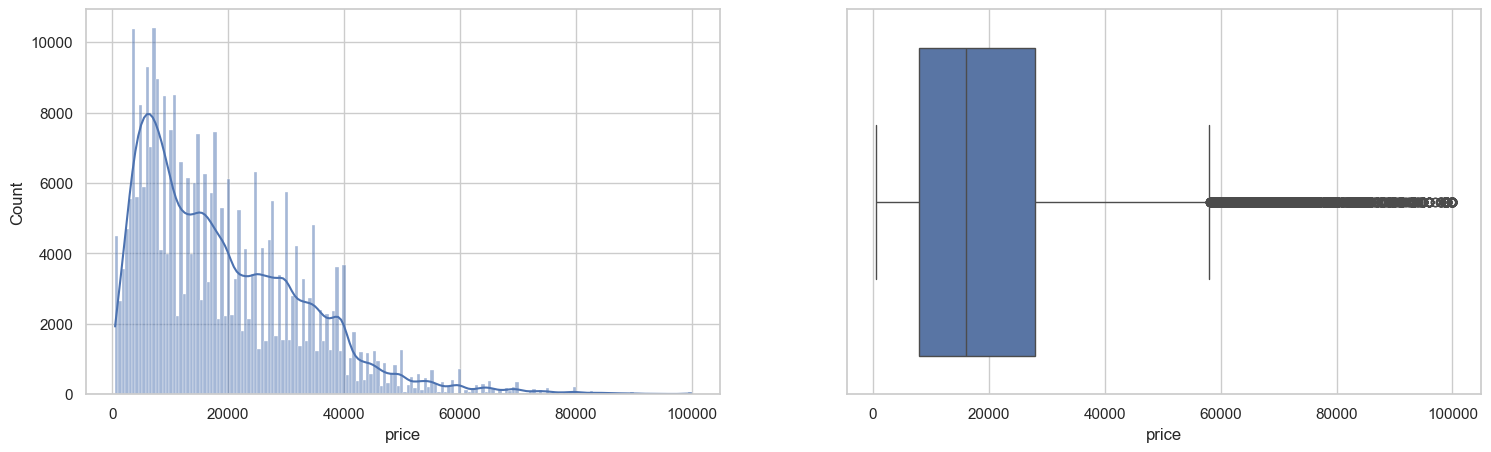

Log10 Target Columns: price
Log10 Target skewness: -0.7509429779566406


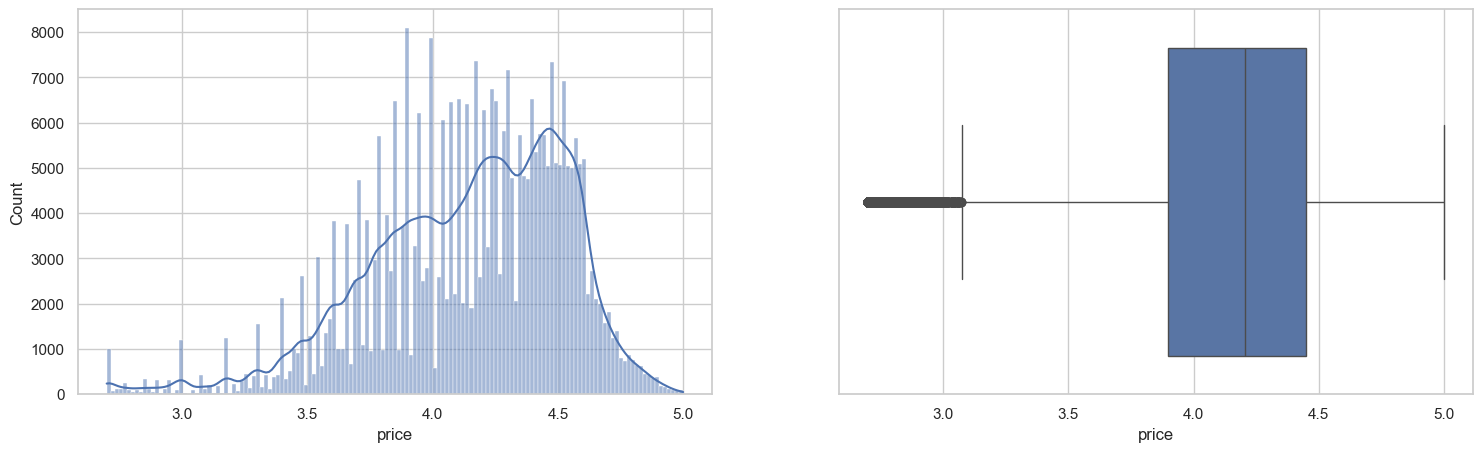

In [56]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

print("Target Columns:", TARGET_COL)
print("Target skewness:", train_data[TARGET_COL].skew())

sns.histplot(train_data[TARGET_COL], kde=True, ax=axes[0])
sns.boxplot(x=train_data[TARGET_COL], ax=axes[1])

plt.show()

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

print("Log10 Target Columns:", TARGET_COL)
print("Log10 Target skewness:", Y_train.skew())

sns.histplot(Y_train, kde=True, ax=axes[0])
sns.boxplot(x=Y_train, ax=axes[1])

plt.show()

### 3.2 Numeric analysis

- Distribution

price


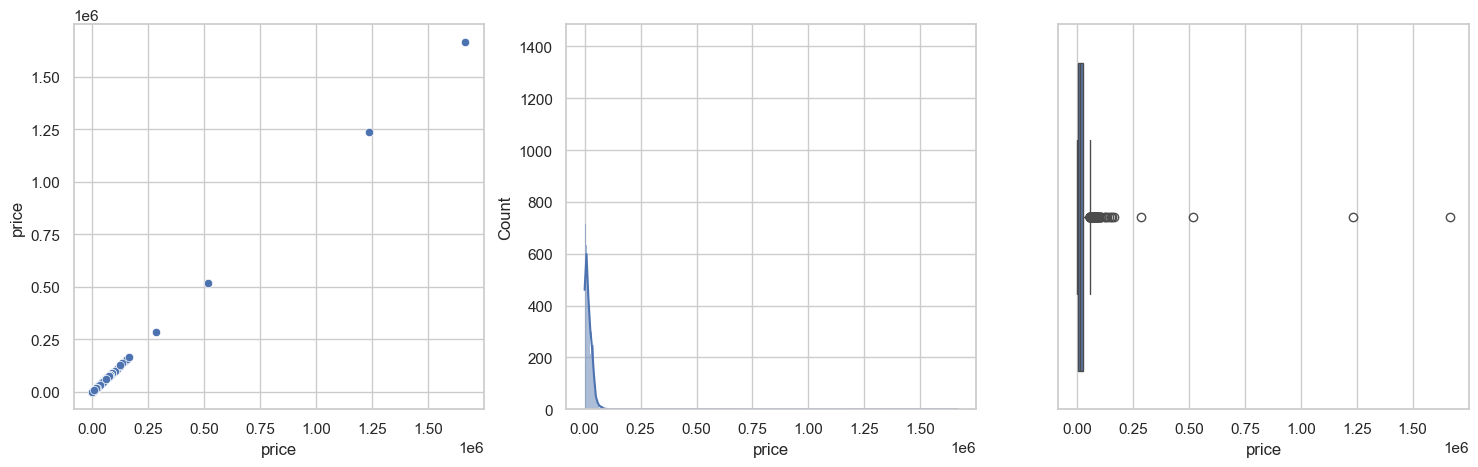

In [41]:
NUM_FEATURES = ['price']
NUM_COL

def visual_analyse_numeric_feature(
        df: pd.DataFrame,
        num_features,
        target,
        rotation=0):

    for feature in num_features:
        fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

        print(feature)

        sns.scatterplot(x=df[feature],y=df[target], ax=axes[0])
        sns.histplot(df[feature], kde=True, ax=axes[1])
        sns.boxplot(x=df[feature], ax=axes[2])

        # subfig = plt.figure(figsize=(18, 5))
        # sns.boxplot(x=pd.cut(train[feature], bins=50, precision=1), y=train[TARGET_COL])
        # plt.xticks(rotation=90)
        # plt.show()

        for ax in axes:
            ax.tick_params(rotation=rotation)
        plt.show()
        plt.show()

visual_analyse_numeric_feature(X_train, NUM_FEATURES, TARGET_COL, rotation=0)

### 3.3 Categoric Analysis

- Distribution

In [ ]:
CAT_FEATURES = []
# CAT_FEATURES = OBJ_COL

def visual_analyse_categoric_feature(
        df: pd.DataFrame,
        cat_features,
        target,
        rotation=0):
    for feature in cat_features:
        fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

        print(feature)

        sns.scatterplot(x=df[feature], y=df[target], ax=axes[0])
        sns.histplot(df[feature], kde=True, ax=axes[1])
        sns.boxplot(x=df[feature], y=df[target], ax=axes[2])

        for ax in axes:
            ax.tick_params(rotation=rotation)
        plt.show()

visual_analyse_categoric_feature(train, CAT_FEATURES, TARGET_COL)

### Correlative Analysis
- pearson
- spearman

In [ ]:
def visual_analyse_corr(
        features: pd.DataFrame,
        target,
        vmin=-1,
        vmax=1,
        annot=False,
        figsize=None,
):
    corr_pearson = features.corr(numeric_only=True,method="pearson")
    corr_spearman = features.corr(numeric_only=True,method="spearman")

    plt.figure(figsize=figsize)
    sns.heatmap(corr_pearson, vmin=vmin, vmax=vmax, annot=annot, square=True, cmap="coolwarm")
    plt.show()

    plt.figure(figsize=figsize)
    sns.heatmap(corr_spearman, vmin=vmin, vmax=vmax, annot=annot, square=True, cmap="coolwarm")
    plt.show()

    # display(corr_pearson[target].sort_values(ascending=False).head(10))
    # display(corr_spearman[target].sort_values(ascending=False).head(10))

visual_analyse_corr(train, TARGET_COL, figsize=(18, 18))

In [ ]:
def corr_report(
        features: pd.DataFrame,
        target,):

    corr_pearson = features.corr(numeric_only=True,method="pearson")
    corr_spearman = features.corr(numeric_only=True,method="spearman")

    # 2. Correlation with target
    target_corr_pearson = corr_pearson[target]
    target_corr_spearman = corr_spearman[target]

    target_corr = pd.DataFrame({
        "Pearson": target_corr_pearson,
        "Spearman": target_corr_spearman,
        "Differ": target_corr_pearson - target_corr_spearman
    })

    display(target_corr.sort_values(by="Spearman", ascending=False).head(10))
    display(target_corr.sort_values(by="Spearman", ascending=True).head(5))

corr_report(train, TARGET_COL)

## 4 Train/Valid Split(5 min)

In [ ]:
SELECTED_FEATURE = [
    "OverallQual",
    "OverallCond",

    "GrLivArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "2ndFlrSF",

    "GarageCars",
    "GarageArea",

    "TotRmsAbvGrd",
    "BedroomAbvGr",
    "FullBath",

    "YearBuilt",
    "YearRemodAdd",

    "Neighborhood",

    "LotArea",
]

In [ ]:
X = train[SELECTED_FEATURE].copy()
Y = train[TARGET_COL].copy()

X_train, X_valid, Y_train, Y_valid = train_test_split(X, Y, test_size=0.2, random_state=42)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("Y_train:", Y_train.shape)
print("Y_valid:", Y_valid.shape)
print(X_train.index.equals(Y_train.index))
print(X_valid.index.equals(Y_valid.index))

XY_train = pd.concat([X_train, Y_train], axis=1)
print(XY_train.shape)

display(X_train)
display(Y_train)

## 5 Feature Engineering (15 min) 特征工程

- Feature Selection
  - by correlation
  - by importance
- Feature Creation
- Feature Combination
  - Total/Sum/Count
- Feature Transformation
  - Log Transformation
  - Polynomial Transformation
  - Binning
- Feature Extraction
  - Date/Time Feature: Festival, Used time
  - Text Feature: description → vector(TF-IDF/embeddings)
  - Image Feature: pixel/color/shape


## 6 Preprocess (15 mins) 预处理

- Missing value handle: Numeric, Categoric
- Outlier handle: delete, replace, transform
- Feature Encoding
  - One-Hot Encoding
  - Ordinal Encoding
- Feature Scaling
  - Standardization: mean → 0, std → 1
  - Normalization: value → [0~1]

In [282]:
NUM_X_TRAIN_FEATURES = X_train.select_dtypes(
    include="number"
).columns.tolist()

CAT_X_TRAIN_FEATURES = X_train.select_dtypes(
    exclude="number"
).columns.tolist()

print("Numerical:", NUM_X_TRAIN_FEATURES)
print("\nCategorical:", CAT_X_TRAIN_FEATURES)

Numerical: ['OverallQual', 'OverallCond', 'GrLivArea', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'GarageCars', 'GarageArea', 'TotRmsAbvGrd', 'BedroomAbvGr', 'FullBath', 'YearBuilt', 'YearRemodAdd', 'LotArea']

Categorical: ['Neighborhood']


### 6.1 Missing Value Handle
No missing value, no need to handle

In [ ]:
print("Missing report of X_Train:")
display(missing_report(X_train, columns=SELECTED_FEATURE))

### 6.2 Duplicated Value Handle
No global duplicated entity, no need to handle

In [ ]:
print("Duplicated report by id columns of Train:")
display(duplicated_entities_report(train, [ID_COL]))

print("Duplicated report by identify columns of Train:")
display(duplicated_entities_report(train, IDENTIFY_COLS))

### 6.3 Outlier Handle
Basically normal, no need to handle

In [257]:
print("Outliers report of selected features:")
display(outlier_report(XY_train, XY_train.columns.tolist()))

Outliers report of selected features:


,count,Q1,Q3,IQR,lower,upper,outlier_count,outlier_rate
OverallCond,1168,5.00,6.00,1.00,3.500,7.500,99,0.084760
LotArea,1168,7587.25,11700.00,4112.75,1418.125,17869.125,54,0.046233
SalePrice,1168,130000.00,214925.00,84925.00,2612.500,342312.500,48,0.041096
TotalBsmtSF,1168,796.00,1299.25,503.25,41.125,2054.125,47,0.040240
BedroomAbvGr,1168,2.00,3.00,1.00,0.500,4.500,26,0.022260
TotRmsAbvGrd,1168,5.00,7.00,2.00,2.000,10.000,25,0.021404
GrLivArea,1168,1145.75,1792.00,646.25,176.375,2761.375,23,0.019692
GarageArea,1168,341.00,576.00,235.00,-11.500,928.500,18,0.015411
1stFlrSF,1168,888.00,1396.75,508.75,124.875,2159.875,13,0.011130
YearBuilt,1168,1953.00,2001.00,48.00,1881.000,2073.000,5,0.004281


### 6.4 Logic Consistency Handle

No logic consistency, no need to handle

In [258]:
print("Logic inconsistency check of selected features:")
TRAIN_RULES = [
    ["Built year in future:", lambda df: df['YearBuilt'] > 2010],
    ["Built year later than RemodAdd", lambda df: df['YearBuilt'] > df['YearRemodAdd']],
]
for RULE in TRAIN_RULES:
    check_rule(X_train, RULE)

Logic inconsistency check of selected features:
Built year in future: 0
Built year later than RemodAdd 0


### 6.5 Categoric Encode
- One-Hot Encoding: for nominal categorical feature

In [259]:
for col in CAT_X_TRAIN_FEATURES:
    print(col, train[col].nunique(), train[col].unique())

Neighborhood 25 ['CollgCr' 'Veenker' 'Crawfor' 'NoRidge' 'Mitchel' 'Somerst' 'NWAmes'
 'OldTown' 'BrkSide' 'Sawyer' 'NridgHt' 'NAmes' 'SawyerW' 'IDOTRR'
 'MeadowV' 'Edwards' 'Timber' 'Gilbert' 'StoneBr' 'ClearCr' 'NPkVill'
 'Blmngtn' 'BrDale' 'SWISU' 'Blueste']


### 6.6 Target Skew

Target skewness: 1.743128561420854


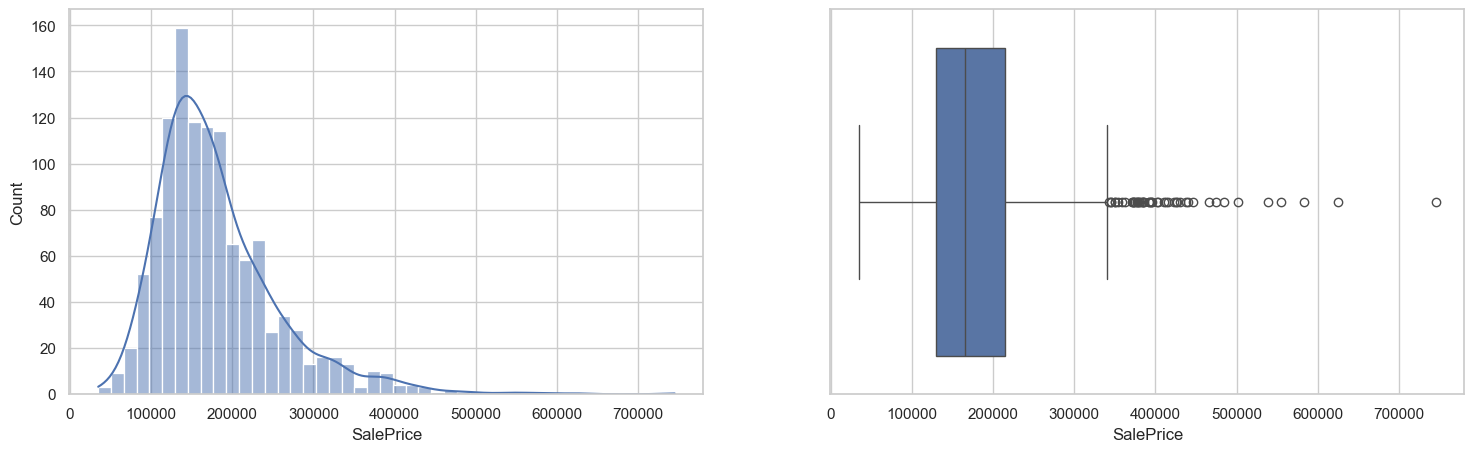

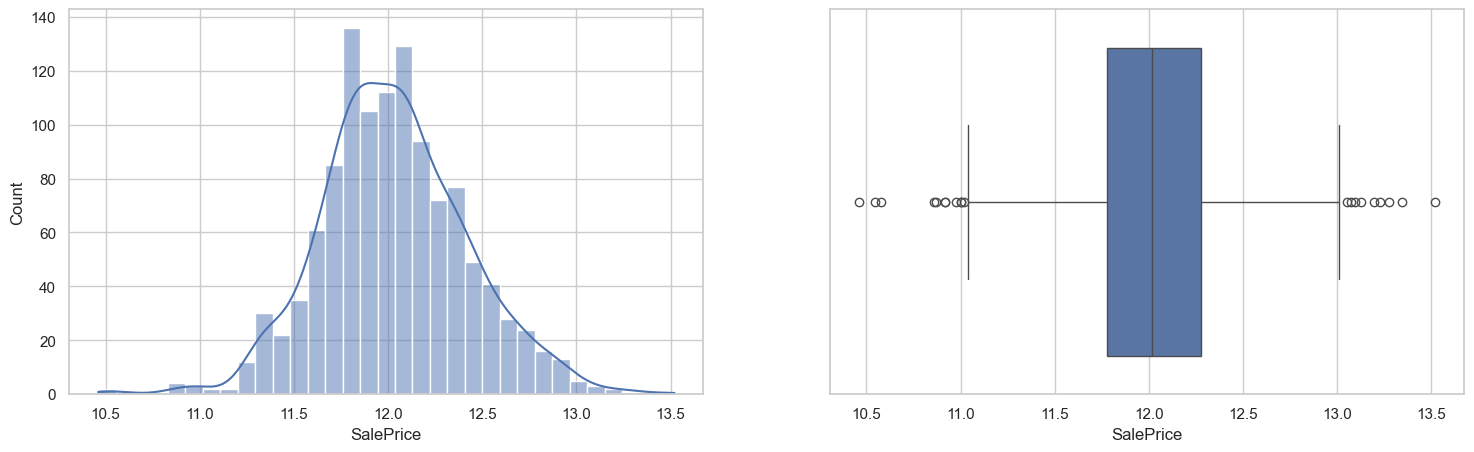

In [278]:
print("Target skewness:", Y_train.skew())

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

sns.histplot(Y_train, kde=True, ax=axes[0])
sns.boxplot(x=Y_train, ax=axes[1])

Y_train_log = np.log(Y_train)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

sns.histplot(Y_train_log, kde=True, ax=axes[0])
sns.boxplot(x=Y_train_log, ax=axes[1])

plt.show()

### 6.6 Pipeline

In [286]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, NUM_X_TRAIN_FEATURES),
    ("cat", categorical_transformer, CAT_X_TRAIN_FEATURES),
])

In [ ]:
visual_analyse_numeric_feature(XY_train, NUM_X_TRAIN_FEATURES ,TARGET_COL)

In [ ]:
visual_analyse_categoric_feature(XY_train, CAT_X_TRAIN_FEATURES, TARGET_COL, rotation=90)

In [ ]:
visual_analyse_corr(XY_train, TARGET_COL)

In [ ]:
corr_report(XY_train, TARGET_COL)

## 7 Model Training (30 mins) 模型训练

- Baseline model Select
  - Regression: LinealRegression, GradientBoost
- Model Training
- Valid Predict

In [301]:
linear_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("regressor", LinearRegression()),
])

linear_model.fit(X_train, Y_train_log)
linear_pred_log = linear_model.predict(X_valid)

linear_pred = np.exp(linear_pred_log)

print("Y_valid:", Y_valid.shape)
print("linear_pred:", linear_pred.shape)

Y_valid: (292,)
linear_pred: (292,)


In [302]:
result_df = pd.DataFrame({
    "actual": Y_valid,
    "predicted": linear_pred,
    "error": Y_valid-linear_pred,
    "error_rate": (Y_valid-linear_pred)/Y_valid
})

display(result_df)

,actual,predicted,error,error_rate
892,154500,155909.231633,-1409.231633,-0.009121
1105,325000,306553.926985,18446.073015,0.056757
413,115000,110198.897047,4801.102953,0.041749
522,159000,162180.973900,-3180.973900,-0.020006
1036,315500,285336.923925,30163.076075,0.095604
...,...,...,...,...
479,89471,121391.649685,-31920.649685,-0.356771
1361,260000,251353.162073,8646.837927,0.033257
802,189000,190357.463671,-1357.463671,-0.007182
651,108000,103858.143660,4141.856340,0.038351


## 8 Evaluation (10 mins) 评估指标

In [303]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

mae = mean_absolute_error(
    Y_valid,
    linear_pred,
)

rmse = mean_squared_error(
    Y_valid,
    linear_pred,
) ** 0.5

r2 = r2_score(
    Y_valid,
    linear_pred,
)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

MAE : 18052.72
RMSE: 28377.80
R²  : 0.8950


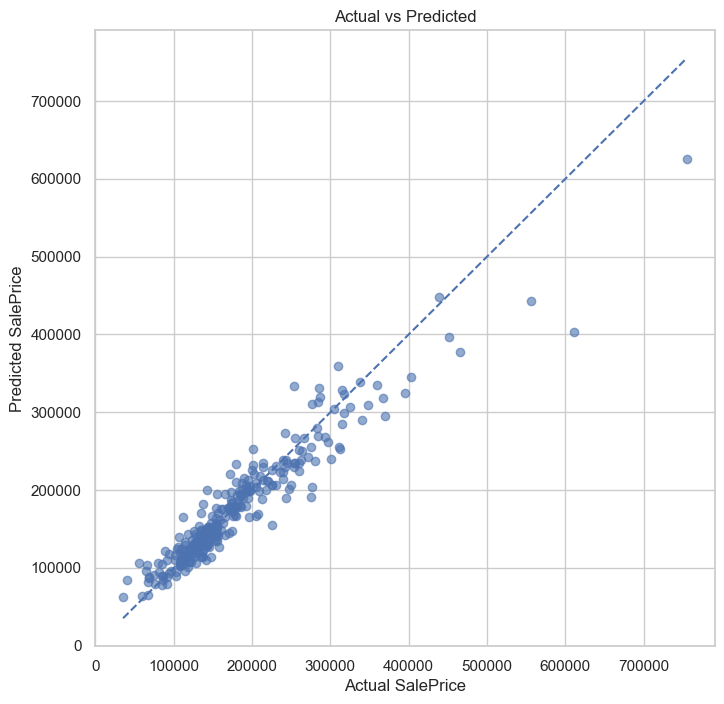

In [304]:
plt.figure(figsize=(8, 8))

plt.scatter(
    Y_valid,
    linear_pred,
    alpha=0.6,
)

plt.plot(
    [Y_valid.min(), Y_valid.max()],
    [Y_valid.min(), Y_valid.max()],
    linestyle="--",
)

plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Actual vs Predicted")

plt.show()

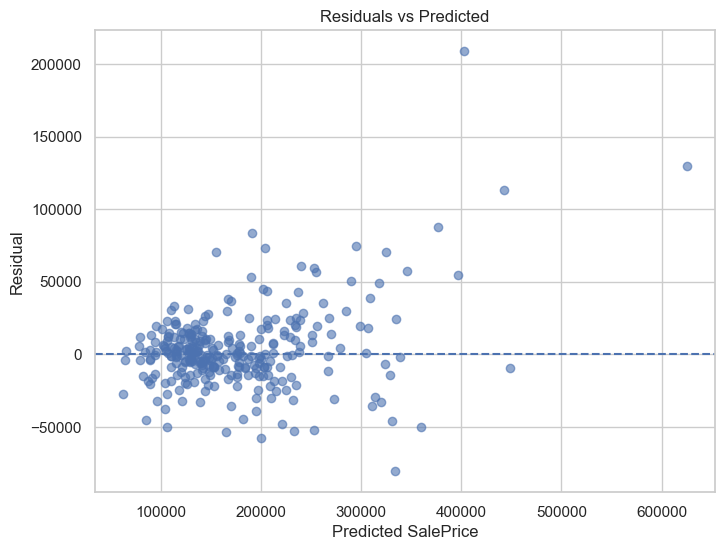

In [306]:
plt.figure(figsize=(8, 6))

residuals = Y_valid - linear_pred

plt.scatter(
    linear_pred,
    residuals,
    alpha=0.6,
)

plt.axhline(
    0,
    linestyle="--",
)

plt.xlabel("Predicted SalePrice")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted")

plt.show()

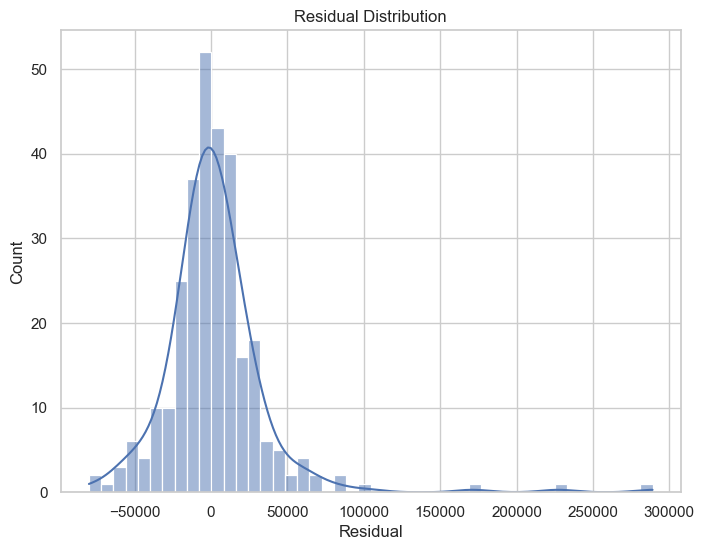

In [298]:
plt.figure(figsize=(8, 6))

sns.histplot(
    residuals,
    kde=True,
)

plt.xlabel("Residual")
plt.title("Residual Distribution")

plt.show()

## 9 Conclution

